In [ ]:
Content
1. Scalability

# 1. Scalability

In [ ]:
Server scalability is the ability of a system (server or infrastructure) to handle increased load — such as more users, data, 
 or requests — by adding resources (CPU, memory, instances) without affecting performance.

Why Required?
    - User base growth (launch new product, or in new region)
    - Increasing data volume (analytics)
    - Peak EVent (sale)
    - Avoid downtime
    - Meet performance SLAs (Service level agreements), like 99% uptime, API response in 200ms

Challenges in Scaling
    1. Latency
        • Delay between request and response
        • Causes: network hops,
        slow DB queries, synchronous calls
        • Amplified in microservices/distributed systems
    2. Bottlenecks
        • One slow component = system-wide slowdown
            Examples: DB locks, memory limits, single-threaded processing
        • Hard to predict as load grows
    3. Downtime
        • More nodes = more failure points
        • Updates, redeployments, scaling events can cause outages
        • High availability becomes harder
    4. Cost
        • Infrastructure isnt free — CPU, RAM, bandwidth
        • Autoscaling without limits = budget nightmare
        • Over-provisioning = wasted spend

# How to Scale a system?
 1. adding API Gateway -> 
       - Routed request to /order Load Balancer   --> multiple EC2 order Server.
       - Routed request to /products Load Balancer   --> multiple EC2 product Server.
  2. Caching
       - For static content (images/ videos/ assets) --> CDN
       - For user data for last few N days, and other constant data  --> you first check in Redis if availble then return else check in DB.
  3. Use of Labda functions/ serverless, if possible.
  4. Authentication: Stateless
  5. Architecture: Micro-services.
  6. DB: 
      - Use NoSQL DB where ever possible.
      - SQL: a. Check if Indexes and query can be optimized.
      - SQL: b. Use of Read Replicas, then Partitioning and then Sharding.
      - SQL: c. 
      - SQL: Optimistic Locking in DB.
      - SQL: Clustered index on tables, clustered key should always be monotonic in increasing order.
      - SQL: Index Only scan, over Index scan.
  7. Auto-Scaling: Good for gradual increase in load.
          - Bad to handle sudden spike and decrease in load.


# How to build High Throughput Systems          
1. High Throughput System
    - Throughput is amount of work a system can handle per unit time.
    - requests/ messages per seconds.
    - How to build such systems:
        1. Parallel Processing: Multiple requests in parallel using load balancers
        2. Async Processing: Message queues
        3. Data Handeling:
            - Batch DB calls
            - Caching (redis)
        4. DB
            - Partitioning

2. Latency:
    - Time taken for one request    



# How to Optimize DB:
   1. Query: Explain and Explain Analyse

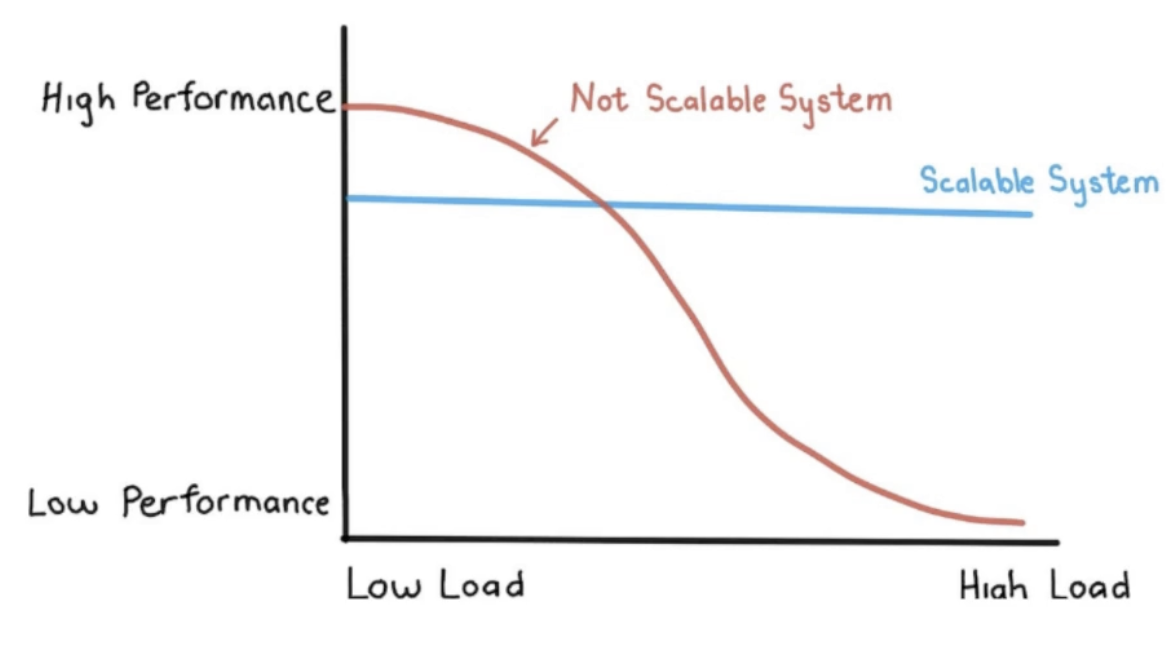
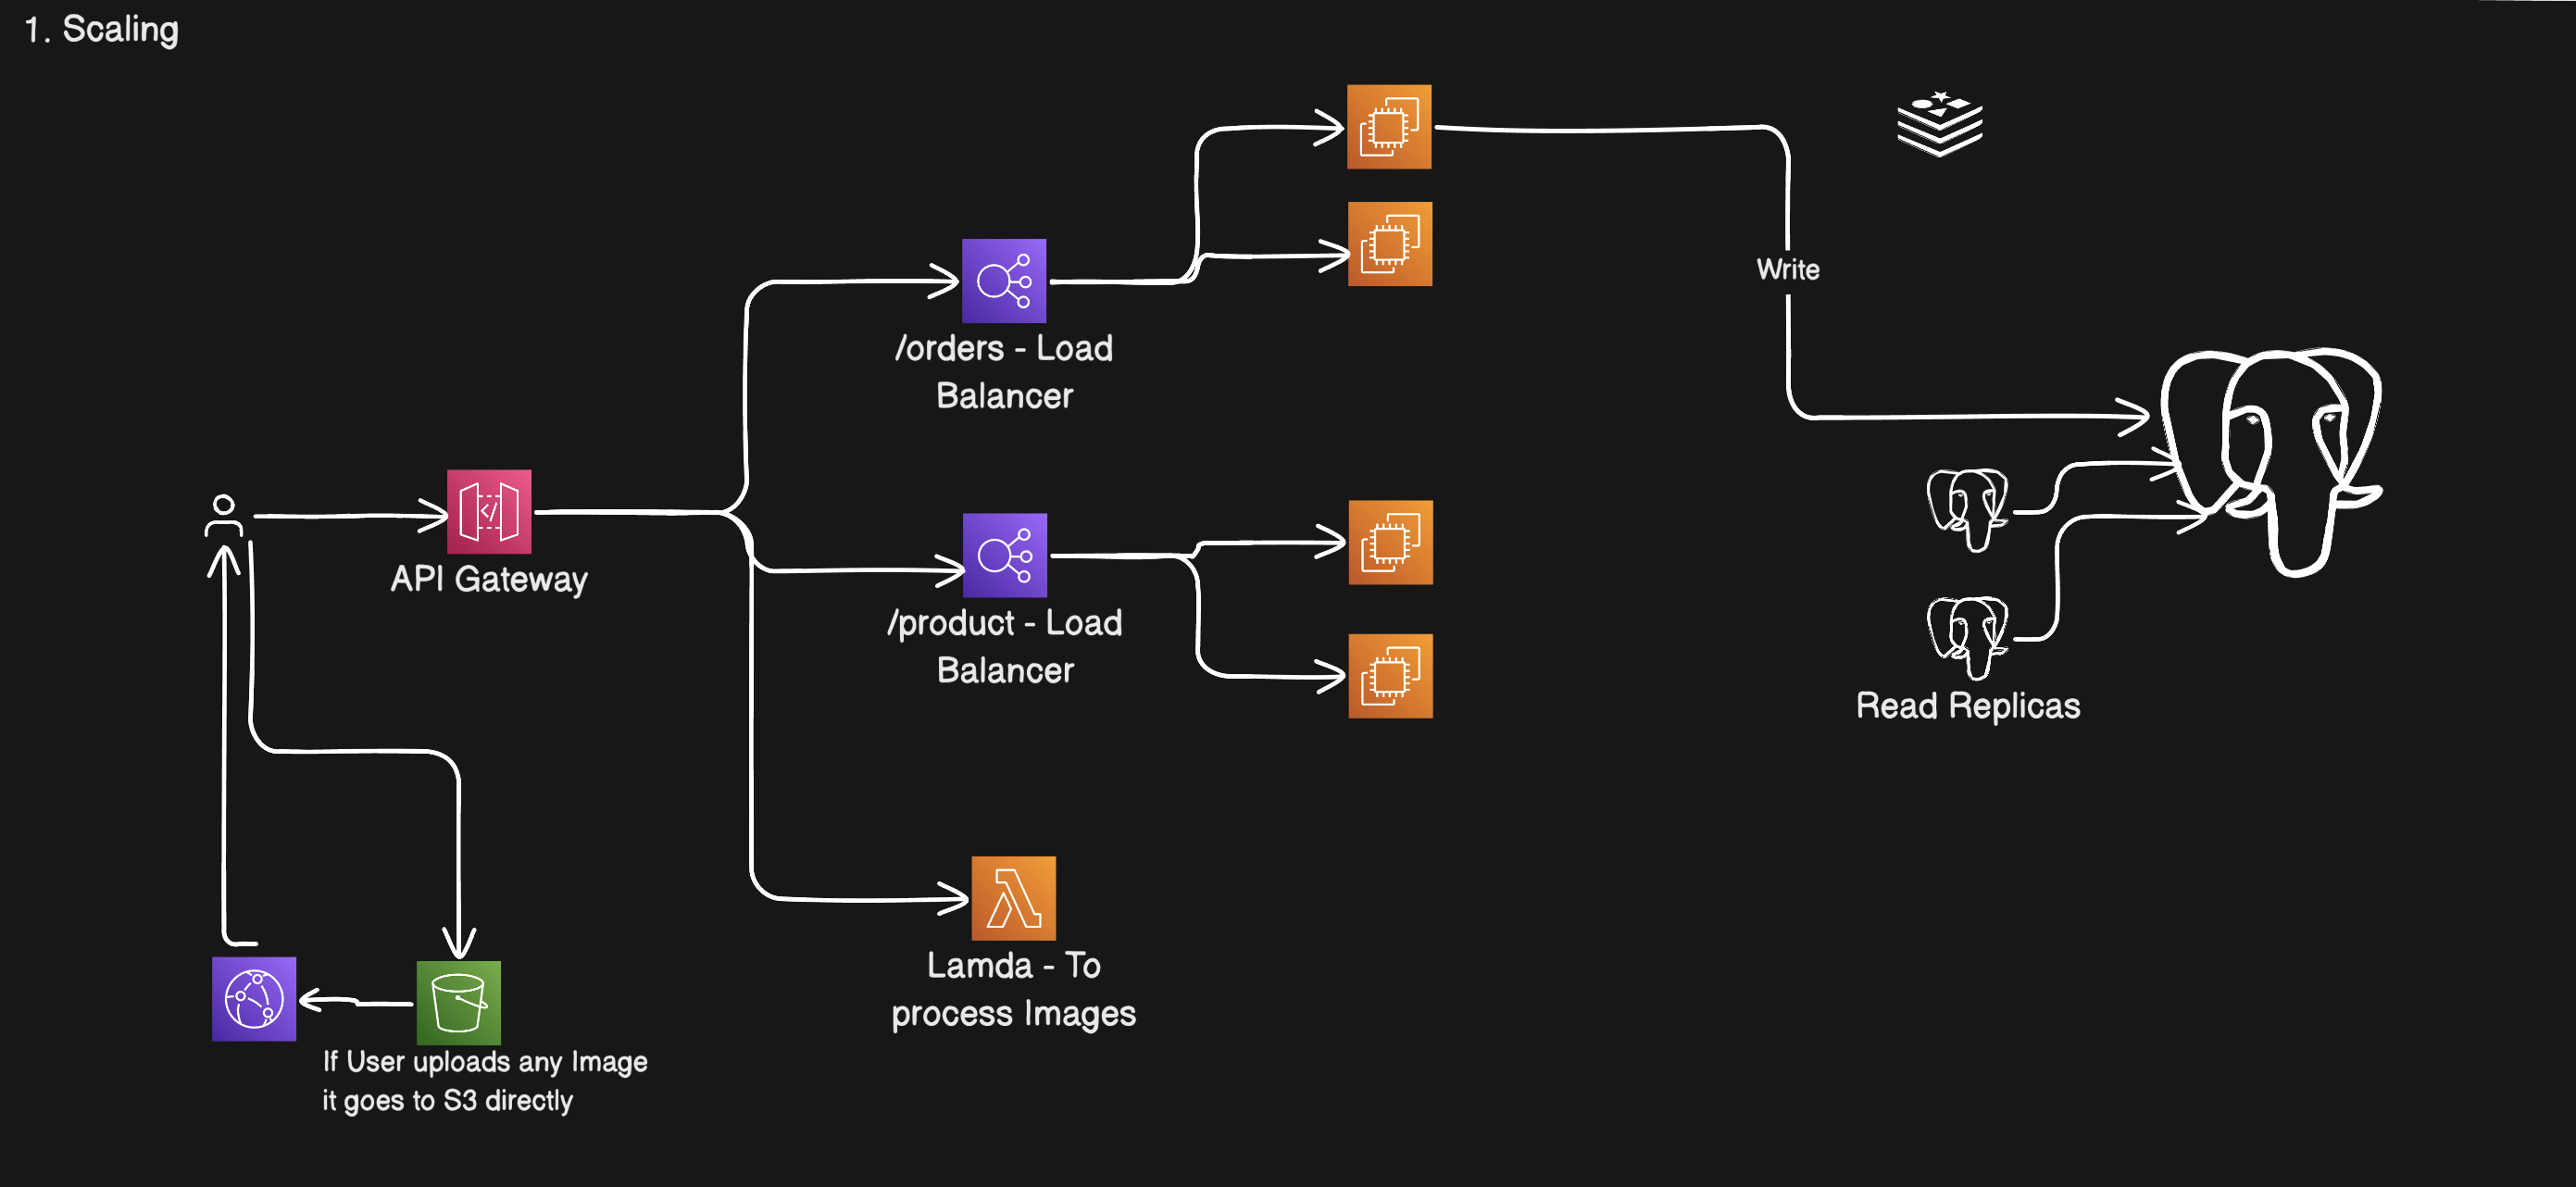


In [ ]:
# Vertical and Hotizontal Scaling
1. Vertical (Scaling Up)
    - Add more resources (CPU, RAM) to the same server.
    - Easier to implement

Cons:
    - has hardware limits, single point of failure

2. Horizontal Scaling
    - Adding more servers to handle load in parallel
    - Multiple smaller servers
    - Complex to implement
	- Load distributed using Load Balancer
    - It requires stateless design
    - More fault-tolerant and elastic

3. Diagonal
    - Start with Vertical, then Horizonatal


# Load Balancing
Why Load Balancing is required
    - A Load Balancer (LB) is a reverse proxy that distributes incoming network traffic across multiple backend servers, to ensure:
        - High Availability: Ensures system uptime even under high traffic.
        - Traffic Distribution: Spreads requests evenly across servers.
        - Prevents Overload: Avoids overburdening a single server.
        - Improves Performance: Reduces latency and enhances response times.
        - Handles Failures Gracefully: Redirects traffic in case of server failure.
        - Supports Scalability: Helps scale systems efficiently.
        - Prevent overload on any single server
        - Improves Reliability

Core Responsibilities
	•	Distribute traffic across multiple servers
	•	Health checks to route traffic away from failed servers
	•	Failover in case a server dies
            - Failover is the process of automatically rerouting traffic away from a failed or unhealthy server to ensure high availability.
            - Pros: No downtime for users, Automatic traffic redirection.
	•	SSL termination (handle HTTPS)
	•	Session persistence (sticky sessions)
	•	Auto-scaling integration
	•	Security filtering (DDoS protection, rate-limiting)

Types of Load Balancer
Based on Layers
    - Layer 4 (Transport Layer): Operates at TCP/UDP level, distributing requests based on network-level data.
        - They make routing decession based on the network level data, like IP address, TCP/ UDP port. 
        - They can not check the url
        - Fast and efficient than Layer 7
        - Example: IP hash, Port-based routing
        - Pros: Fast, lightweight
        - Cons: Less flexible (No content awareness)
    
    - Layer 7 (Application Layer): Operates at HTTP/HTTPS level, .
        - They can route based on url path, cookies, Http/ Https headers and user location.
        - Can make routing decisions based on request content
        - Pros: Smart routing, fine-grained control
        - Cons: Slightly more overhead
        - Example: NGINX, AWS ALB

#FAQ
 1. What happens if a server crashes?
    - Health checks (via LB) will remove that server from the pool and Requests are routed to healthy instances

 2. How does auto-scaling work with load balancers?
	- LB integrates with orchestration platforms (like Kubernetes, ECS, ASG in AWS)
	- Dynamically updates pool as new servers are added/removed

+------------------+--------------------------------------------------------+---------------------------------------------+
| Algorithm        | Description                                            | Use Case                                    |
+------------------+--------------------------------------------------------+---------------------------------------------+
| Round Robin      | Requests go to servers in a loop                      | Equal-capacity servers                      |
| Least Connections| Routes to the server with the fewest active connections| Long-lived connections (e.g., websockets)   |
| IP Hash          | Same client IP always goes to the same server         | Session stickiness without cookies          |
| Weighted         | Assign weights to servers based on capacity           | Heterogeneous servers                       |
| Random           | Randomly selects a server                             | Simple load distribution                    |
| Custom Logic     | Based on response times, headers, geo-location, etc.  | ML models, latency-optimized routing        |
+------------------+--------------------------------------------------------+---------------------------------------------+

In [ ]:
# Session Persistance
    - a load balancing mechanism where a user’s requests are always routed to the same backend server for the duration of a session.
    - This ensures consistency if a user’s session state is stored in memory (server-local) rather than a shared storage like Redis or a DB.
    - Cons: Limits scalability, tight coupling
    
    - When it is required
        - HTTP is statefull
        - If you’re storing session-specific data (e.g., shopping cart, login state) in server memory, routing future requests to a different server could break user flow.
        - Sticky sessions solve this by “pinning” the user to a specific server.
    - Types
        a. IP Hash
            - Load balancer hashes the client’s IP
            - Same IP goes to the same backend
            - Con: ISPs may cause the same IP for multiple users.
        b. Cookie-based (LB-generated cookie)
            - LB sets a cookie like LBSESSIONID=server2
            - On each request, LB reads cookie and routes accordingly
            - Popular in: AWS ALB, NGINX, F5
    - Problems:
        - If AppServer2 fails and user A is pinned there → session is lost if session is stored only in memory.
        - This can be solved by
        	- Use shared session storage (e.g., Redis, Memcached, DB)
        	- Or use JWT tokens (stateless sessions)


In [ ]:
# Autoscaling
    - Automatic adjustment of compute resources based on load.
    - Ensures performance, availability, cost-efficiency.

    - Parameters defined
        - minimum no. of servers
        - maximum no. of servers
        - desired capacity

How scaling works
    - Triggers: CPU usage, Memory usage, Rate request
    - Types: Horizontal and Vertical
    - Scaling Policy: 
        - Reactive Scaling: When certain threshold are crossed.
        - Predictive Scaling: For known traffic patterns, based on trends

Cost Optimization
    - Avoid over-provisioning: Scaling just required enough
    - Use spot instances for batch workloads
    - Rightsize your machine by regularly monitoring
    - Use scale-to-zero or auto-pausing if not required.
    - Monitor proactively instead of reactive, to stay ahead of loads.